# Deep Learning for Text and Sequences  
## Class Notebook for BS AI (5th Semester)

This notebook is prepared from the lecture topic **"Working with text data"** from *Deep Learning with Python*.

### What students will learn
1. How raw text is converted into numbers  
2. What **tokens** are and why **tokenization** is needed  
3. How **one-hot encoding** works for words and characters  
4. What the **hashing trick** is  
5. Why **word embeddings** are better than sparse one-hot vectors  
6. How to use the **Embedding** layer in Keras  
7. How to train a simple **IMDB sentiment classifier**  
8. Why **pretrained embeddings** can help when training data is small  

### Note
The original book examples use older `keras` imports. In this notebook, the code is written with **`tensorflow.keras`** so it works more smoothly in **Google Colab**.

In [4]:
# ============================
# Basic imports for the class
# ============================

import os # Used for operating system functionalities, like path manipulation
import string # Provides string constants, like printable characters
import numpy as np # Fundamental package for numerical computation in Python
import matplotlib.pyplot as plt # Library for creating static, interactive, and animated visualizations

# Keras utilities for text processing and model building
from tensorflow.keras.preprocessing.text import Tokenizer # Utility for text tokenization and vectorization
from tensorflow.keras.preprocessing.sequence import pad_sequences # Utility for padding sequences to a uniform length
from tensorflow.keras.datasets import imdb # Dataset for movie reviews sentiment classification
from tensorflow.keras.models import Sequential # A linear stack of layers for building neural networks
from tensorflow.keras.layers import Embedding, Flatten, Dense # Core layers for neural networks

# Make NumPy output easier to read by suppressing scientific notation for small numbers
np.set_printoptions(suppress=True)

# 1. From text to tokens to vectors

A neural network cannot read raw sentences directly.  
It only works with **numbers**.

So the usual pipeline is:

**Text → Tokens → Numeric vectors → Neural network**

### Important terms
- **Text**: the original sentence or document  
- **Token**: a basic unit such as a word, character, or n-gram  
- **Tokenization**: breaking text into tokens  
- **Vectorization**: converting tokens into numbers  

Let us start with a very small example.

In [5]:
# A simple sentence for demonstration
sample_text = "The cat sat on the mat."

# Very basic tokenization using split()
tokens = sample_text.split()

print("Original text:")
print(sample_text)
print("\nTokens:")
print(tokens)

Original text:
The cat sat on the mat.

Tokens:
['The', 'cat', 'sat', 'on', 'the', 'mat.']


The `split()` method is okay for a toy example, but it is **not perfect** for real NLP work because punctuation and special symbols are not handled carefully.

For teaching purposes, it is a good starting point.

# 2. Word-level one-hot encoding

In **one-hot encoding**, every unique word gets its own integer index.

Then each word is converted into a vector where:
- one position is **1**
- all other positions are **0**

If the vocabulary size is large, the vector becomes large too.

This is why one-hot vectors are:
- sparse
- high-dimensional
- not learned from data

In [6]:
# =======================================
# Word-level one-hot encoding (toy example)
# =======================================

samples = ['The dog sat on the mat.', 'The dog ate my homework.']

# Step 1: Build a word index manually
# This dictionary will store each unique word and assign it a unique integer ID.
token_index = {}

for sample in samples:
    for word in sample.split():
        # Assign a new ID if the word is not already in the index
        if word not in token_index:
            token_index[word] = len(token_index) + 1  # Start IDs from 1 (0 is often reserved for padding)

print("Word index:")
print(token_index)

# Step 2: Create a tensor (multi-dimensional array) to store one-hot vectors
# The shape is (number_of_samples, max_sequence_length, vocabulary_size + 1)
# +1 for vocabulary_size because indices start from 1, leaving 0 unused.
max_length = 10  # maximum number of words per sample to consider
results = np.zeros((len(samples), max_length, max(token_index.values()) + 1))

# Step 3: Fill the tensor with one-hot encoded vectors
for i, sample in enumerate(samples):
    # Iterate over words in each sample, up to max_length
    for j, word in list(enumerate(sample.split()))[:max_length]:
        index = token_index.get(word)
        # If the word exists in our token_index, set the corresponding position to 1
        if index is not None:
            results[i, j, index] = 1.

print("\nShape of result tensor:", results.shape)
print("One-hot vector for the first word in the first sample:")
# Displaying the one-hot vector for the very first word ('The') of the first sample
print(results)

Word index:
{'The': 1, 'dog': 2, 'sat': 3, 'on': 4, 'the': 5, 'mat.': 6, 'ate': 7, 'my': 8, 'homework.': 9}

Shape of result tensor: (2, 10, 10)
One-hot vector for the first word in the first sample:
[[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


### What is the shape here?

The result tensor has shape:

`(number_of_samples, max_length, vocabulary_size + 1)`

That means:
- first axis = which sentence
- second axis = which word position in the sentence
- third axis = one-hot vector for that word

# 3. Character-level one-hot encoding

Instead of treating a sentence as a sequence of **words**, we can also treat it as a sequence of **characters**.

This may be useful in some tasks:
- spelling analysis
- noisy text
- language identification
- character-level text generation

But character sequences are usually longer than word sequences.

In [7]:
# ============================================
# Character-level one-hot encoding (toy example)
# ============================================

samples = ['The cat sat on the mat.', 'The dog ate my homework.']

# Get all printable ASCII characters, which will form our character vocabulary
characters = string.printable
# Create a dictionary mapping each character to a unique integer ID, starting from 1
token_index = dict(zip(characters, range(1, len(characters) + 1)))

max_length = 50 # Maximum number of characters per sample to consider
# Create a tensor to store one-hot vectors for characters
# Shape: (number_of_samples, max_sequence_length, vocabulary_size + 1)
results = np.zeros((len(samples), max_length, max(token_index.values()) + 1))

# Fill the tensor with one-hot encoded vectors for characters
for i, sample in enumerate(samples):
    # Iterate over characters in each sample, up to max_length
    for j, character in enumerate(sample[:max_length]):
        index = token_index.get(character)
        # If the character exists in our token_index, set the corresponding position to 1
        if index is not None:
            results[i, j, index] = 1.

print("Number of printable characters:", len(characters))
print("Result tensor shape:", results.shape)
print("One-hot vector for the first character of the first sample:")
# Displaying the one-hot vector for the very first character ('T') of the first sample
print(results[0, 0])

Number of printable characters: 100
Result tensor shape: (2, 50, 101)
One-hot vector for the first character of the first sample:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]


# 4. Using Keras `Tokenizer`

Instead of writing everything manually, Keras provides utilities for tokenization and vectorization.

This is the practical way to work with text in many beginner projects.

In [8]:
# ======================================
# Using Keras Tokenizer for word encoding
# ======================================

samples = ['The cat sat on the mat.', 'The dog ate my homework.']

# Initialize the Tokenizer, keeping only the 1000 most frequently occurring words
# (in real-world scenarios, this helps manage vocabulary size)
tokenizer = Tokenizer(num_words=1000)

# Build the internal word index based on the provided samples
# It maps words to integer indices based on their frequency.
tokenizer.fit_on_texts(samples)

# Convert text samples into sequences of integer word indices
# Each word is replaced by its corresponding integer ID.
sequences = tokenizer.texts_to_sequences(samples)

# Convert text samples into a binary one-hot-like matrix
# 'binary' mode means each row represents a document, and columns are words.
# A 1 indicates the word is present in the document, 0 if absent (Bag-of-Words style).
one_hot_results = tokenizer.texts_to_matrix(samples, mode='binary')

# Get the word-to-index mapping generated by the tokenizer
word_index = tokenizer.word_index

print("Word index:")
print(word_index)

print("\nSequences:")
print(sequences)

print("\nBinary matrix shape:")
print(one_hot_results.shape)

print("\nBinary matrix:")
print(one_hot_results)

Word index:
{'the': 1, 'cat': 2, 'sat': 3, 'on': 4, 'mat': 5, 'dog': 6, 'ate': 7, 'my': 8, 'homework': 9}

Sequences:
[[1, 2, 3, 4, 1, 5], [1, 6, 7, 8, 9]]

Binary matrix shape:
(2, 1000)

Binary matrix:
[[0. 1. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


### Difference to notice
`texts_to_sequences()` gives a **sequence of word indices**.

For example:
- "The cat sat on the mat." → something like `[1, 2, 3, 4, 1, 5]`

This is very useful because **Embedding layers expect integer sequences**.

# 5. The hashing trick

If the vocabulary is very large, building a complete word dictionary can be expensive.

A shortcut is to use a **hashing trick**:
- hash each word into a fixed-size space
- store the result in a vector of fixed dimensionality

### Advantage
- memory efficient
- simple
- can be used online

### Disadvantage
Two different words may map to the same location. This is called a **hash collision**.

In [9]:
# =======================================
# One-hot hashing trick (toy example)
# =======================================

samples = ['The cat sat on the mat.', 'The dog ate my homework.']

dimensionality = 1000 # The size of the vector space we're hashing into
max_length = 10      # Maximum number of words per sample

# Initialize a tensor to store the hashed one-hot vectors
# Shape: (number_of_samples, max_sequence_length, dimensionality)
results = np.zeros((len(samples), max_length, dimensionality))

for i, sample in enumerate(samples):
    # Iterate over words in each sample, up to max_length
    for j, word in list(enumerate(sample.split()))[:max_length]:
        # Hash the word and take its absolute value, then modulo by dimensionality
        # This maps each word to an index within the fixed-size vector space.
        index = abs(hash(word)) % dimensionality
        results[i, j, index] = 1. # Set the corresponding position to 1

print("Result tensor shape:", results.shape)
print("Hashed vector for the first word in the first sample:")
# Display the hashed vector for the first word of the first sample
print(results[0, 0])

Result tensor shape: (2, 10, 1000)
Hashed vector for the first word in the first sample:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

# 6. Why one-hot encoding is limited

One-hot encoding has a major weakness.

It does **not capture meaning**.

For example:
- `good` and `excellent` are semantically related
- but one-hot encoding treats them as completely different and unrelated

Also, vocabulary size can become huge.

That is why we use **word embeddings**.

# 7. Word embeddings

A **word embedding** is a dense vector representation of a word.

Unlike one-hot vectors, embeddings are:
- **dense**
- **lower-dimensional**
- **learned from data**

### Intuition
Words with similar meaning should have similar vectors.

Examples:
- `good` and `great` should be close
- `cat` and `dog` should be closer than `cat` and `car`

### Two ways to get embeddings
1. **Learn them during training** for your own task  
2. **Use pretrained embeddings** such as GloVe or Word2Vec

In [10]:
# ========================================
# Small demo of the Embedding layer in Keras
# ========================================

# Suppose our vocabulary size is 1000
# and we want each word to have a 64-dimensional embedding.
embedding_layer = Embedding(input_dim=1000, output_dim=64)

print(embedding_layer)

<Embedding name=embedding, built=False>


In [11]:
# =========================================================
# Let us pass a fake batch of integer sequences to the layer
# =========================================================

# 2 samples, each of length 5
dummy_sequences = np.array([
    [1, 5, 20, 7, 9],
    [2, 8, 15, 3, 0]
])

embedded_output = embedding_layer(dummy_sequences)

print("Input shape:", dummy_sequences.shape)
print("Output shape:", embedded_output.shape)

Input shape: (2, 5)
Output shape: (2, 5, 64)


### What happened?

Input shape: `(samples, sequence_length)`  
Output shape: `(samples, sequence_length, embedding_dim)`

So if:
- sequence length = 5
- embedding dimension = 64

then each word index is replaced by a vector of length 64.

# 8. IMDB sentiment classification with an Embedding layer

Now we will train a small sentiment classifier using the **IMDB movie review dataset**.

### Goal
Predict whether a review is:
- **positive**
- **negative**

### Idea
1. Load IMDB data as integer sequences  
2. Pad sequences to the same length  
3. Pass them through an `Embedding` layer  
4. Flatten the output  
5. Use a `Dense` layer for binary classification

In [12]:
# =========================================
# Load and prepare the IMDB dataset
# =========================================

max_features = 10000   # only consider the top 10,000 most frequent words in the dataset
maxlen = 20            # only keep the first 20 words of each review to standardize length

# Load the IMDB dataset
# x_train, x_test are sequences of word indices
# y_train, y_test are sentiment labels (0 for negative, 1 for positive)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences so every review has the same length (maxlen)
# If a review is shorter than maxlen, it's padded with zeros.
# If a review is longer than maxlen, it's truncated.
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("x_train shape:", x_train.shape) # (num_training_samples, maxlen)
print("x_test shape:", x_test.shape)   # (num_test_samples, maxlen)
print("y_train shape:", y_train.shape) # (num_training_samples,)
print("y_test shape:", y_test.shape)   # (num_test_samples,)

print("\nExample review as word indices:")
print(x_train[0])

print("\nExample label:")
print(y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
x_train shape: (25000, 20)
x_test shape: (25000, 20)
y_train shape: (25000,)
y_test shape: (25000,)

Example review as word indices:
[  65   16   38 1334   88   12   16  283    5   16 4472  113  103   32
   15   16 5345   19  178   32]

Example label:
1


### Why do we pad sequences?

Neural networks work with tensors of fixed shape inside a batch.

But text reviews have different lengths.

So we:
- **truncate** long reviews
- **pad** short reviews with zeros

In [13]:
# =========================================
# Build the baseline Embedding model
# =========================================

# Initialize a Sequential model (a linear stack of layers)
model = Sequential([
    # Embedding layer: Converts integer indices into dense vectors of fixed size.
    # input_dim: Vocabulary size (max_features = 10000 words).
    # output_dim: Dimension of the dense embedding (8 dimensions per word).
    # input_length: Length of input sequences (maxlen = 20 words).
    # Note: input_length is deprecated in newer Keras versions and is often inferred.
    Embedding(input_dim=max_features, output_dim=8),
    # Flatten layer: Flattens the 3D output of the Embedding layer (batch_size, maxlen, output_dim)
    # into a 2D tensor (batch_size, maxlen * output_dim) so it can be fed to a Dense layer.
    Flatten(),
    # Dense layer: A fully connected layer with a single output neuron.
    # Activation 'sigmoid' is used for binary classification, outputting a probability between 0 and 1.
    Dense(1, activation='sigmoid')
])

# Compile the model: Configure the learning process
model.compile(
    optimizer='rmsprop', # Optimization algorithm (e.g., 'adam', 'sgd')
    loss='binary_crossentropy', # Loss function for binary classification
    metrics=['accuracy'] # Metric to monitor during training
)

# Print a summary of the model's architecture, including layer types, output shapes, and number of parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model explanation
- `Embedding(10000, 8)` means:
  - there are at most 10,000 words
  - each word becomes an 8-dimensional vector

- `Flatten()` changes a 3D tensor into 2D so it can be passed to a Dense layer

- `Dense(1, activation='sigmoid')` predicts a value between 0 and 1 for binary classification

In [14]:
# =========================================
# Train the model
# =========================================

# Train the model using the training data
history = model.fit(
    x_train, # Training input sequences
    y_train, # Training target labels
    epochs=10, # Number of times to iterate over the entire training dataset
    batch_size=32, # Number of samples per gradient update
    validation_split=0.2, # Fraction of the training data to be used as validation data
    verbose=1 # Display progress bar during training
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6289 - loss: 0.6684 - val_accuracy: 0.6936 - val_loss: 0.6239
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7502 - loss: 0.5509 - val_accuracy: 0.7220 - val_loss: 0.5375
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7868 - loss: 0.4694 - val_accuracy: 0.7410 - val_loss: 0.5094
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8102 - loss: 0.4258 - val_accuracy: 0.7482 - val_loss: 0.5011
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8263 - loss: 0.3953 - val_accuracy: 0.7524 - val_loss: 0.5012
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8396 - loss: 0.3701 - val_accuracy: 0.7506 - val_loss: 0.5044
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8528 - loss: 0.3482 - val_accuracy: 0.7544 - val_loss: 0.5097
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8629 - loss: 0.3279 - val_accuracy: 0.

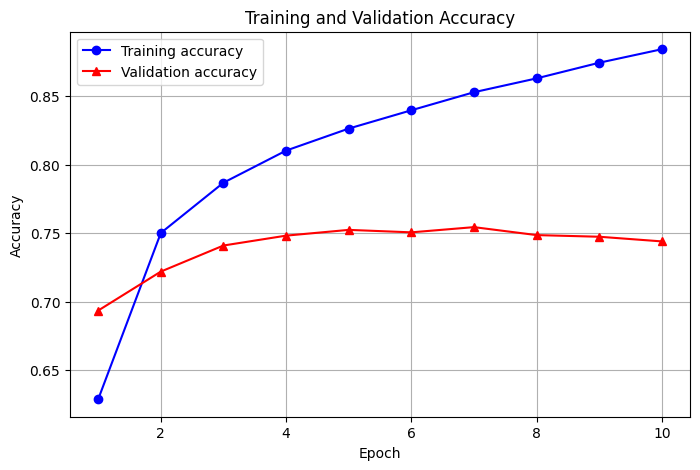

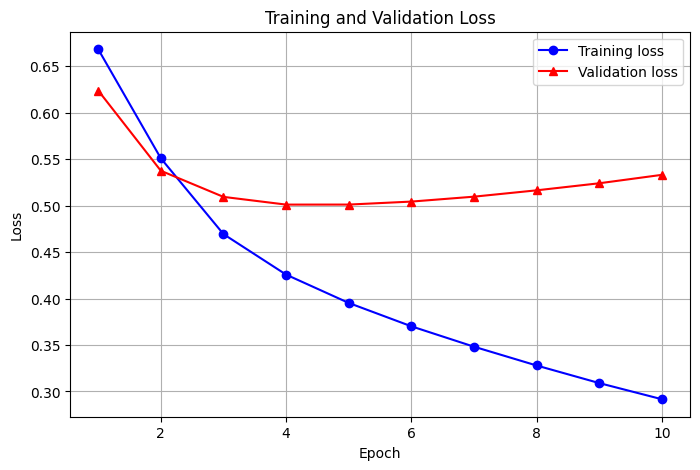

In [15]:
# =========================================
# Plot training and validation accuracy/loss
# =========================================

# Get training and validation accuracy from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Get training and validation loss from the training history
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create a range of epochs for the x-axis of the plots
epochs = range(1, len(acc) + 1)

# Plot Training and Validation Accuracy
plt.figure(figsize=(8, 5)) # Set the figure size
plt.plot(epochs, acc, 'bo-', label='Training accuracy') # Plot training accuracy with blue circles and solid line
plt.plot(epochs, val_acc, 'r^-', label='Validation accuracy') # Plot validation accuracy with red triangles and dashed line
plt.title('Training and Validation Accuracy') # Set the plot title
plt.xlabel('Epoch') # Set the x-axis label
plt.ylabel('Accuracy') # Set the y-axis label
plt.legend() # Display the legend for the labels
plt.grid(True) # Add a grid to the plot
plt.show() # Display the plot

# Plot Training and Validation Loss
plt.figure(figsize=(8, 5)) # Set the figure size
plt.plot(epochs, loss, 'bo-', label='Training loss') # Plot training loss with blue circles and solid line
plt.plot(epochs, val_loss, 'r^-', label='Validation loss') # Plot validation loss with red triangles and dashed line
plt.title('Training and Validation Loss') # Set the plot title
plt.xlabel('Epoch') # Set the x-axis label
plt.ylabel('Loss') # Set the y-axis label
plt.legend() # Display the legend for the labels
plt.grid(True) # Add a grid to the plot
plt.show() # Display the plot

# 9. Discussion of the baseline IMDB model

This model is simple and useful for teaching, but it has an important limitation.

### Problem
After the `Embedding` layer, we use `Flatten()`.

This means the model does **not learn the full sequence structure very well**.

For example, it may fail to understand subtle differences like:
- "this movie is a bomb"
- "this movie is the bomb"

Even though the words are similar, the meanings are different.

### Better models later in the chapter
- **RNNs**
- **LSTMs / GRUs**
- **1D CNNs**

These models handle word order and local patterns more effectively.

In [16]:
# =========================================
# Evaluate on the test set
# =========================================

# Evaluate the trained model on the unseen test data
# verbose=0 means no output during evaluation.
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

# Print the test loss and test accuracy, formatted to 4 decimal places
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.5234
Test accuracy: 0.7528


# 10. Pretrained word embeddings

Sometimes we do not have enough labeled data.

In such cases, learning embeddings from scratch may not work very well.

A solution is to use **pretrained embeddings**.

### Examples
- **Word2Vec**
- **GloVe**

These embeddings are learned from very large text collections and often capture useful language structure.

### Why they help
If training data is small, pretrained embeddings can give the model a better starting point.

# 11. Optional Colab exercise: using pretrained GloVe embeddings

This section is kept **optional** because it needs external files.

To run it in Colab, students should first upload:
1. the raw **IMDB** folder (`aclImdb`)
2. the **GloVe** file such as `glove.6B.100d.txt`

After that, the following cells can be run.

> Teacher note: this is good for demonstration, but it may take more setup time in class.

In [17]:
# =========================================
# OPTIONAL: Set your paths here after upload
# =========================================

# Example:
# imdb_dir = '/content/aclImdb'
# glove_dir = '/content/glove.6B'

imdb_dir = '/content/aclImdb'      # change if needed
glove_dir = '/content/glove.6B'    # change if needed

In [18]:
# =========================================
# OPTIONAL: Read raw IMDB training reviews
# =========================================

labels = [] # List to store sentiment labels (0 for negative, 1 for positive)
texts = []  # List to store the raw text of movie reviews

train_dir = os.path.join(imdb_dir, 'train') # Construct the path to the training directory

# Check if the training directory exists
if os.path.exists(train_dir):
    # Iterate through 'neg' (negative) and 'pos' (positive) review subdirectories
    for label_type in ['neg', 'pos']:
        dir_name = os.path.join(train_dir, label_type)
        # Iterate through each file in the subdirectory
        for fname in os.listdir(dir_name):
            if fname.endswith('.txt'): # Process only text files
                # Open and read the content of each review file
                with open(os.path.join(dir_name, fname), encoding='utf-8') as f:
                    texts.append(f.read())
                # Assign the corresponding label (0 for negative, 1 for positive)
                labels.append(0 if label_type == 'neg' else 1)

    print("Number of training texts:", len(texts))
    print("Number of labels:", len(labels))
else:
    print("Training directory not found. Please upload the IMDB dataset first.")

Training directory not found. Please upload the IMDB dataset first.


In [19]:
# =========================================
# OPTIONAL: Tokenize the raw IMDB texts
# =========================================

maxlen = 100 # Maximum length of sequences (number of words per review)
training_samples = 200 # Number of samples to use for a small training set
validation_samples = 10000 # Number of samples to use for a small validation set
max_words = 10000 # Consider only the top `max_words` frequent words

# Proceed only if texts were successfully loaded
if len(texts) > 0:
    # Initialize Tokenizer to vectorize text into integer sequences
    tokenizer = Tokenizer(num_words=max_words)
    # Build the word index from the raw texts
    tokenizer.fit_on_texts(texts)
    # Convert texts to sequences of integers
    sequences = tokenizer.texts_to_sequences(texts)

    word_index = tokenizer.word_index # Get the word-to-index mapping
    print('Found %s unique tokens.' % len(word_index))

    # Pad sequences to ensure uniform length (`maxlen`)
    data = pad_sequences(sequences, maxlen=maxlen)
    labels_array = np.asarray(labels) # Convert labels list to a NumPy array

    print('Shape of data tensor:', data.shape)
    print('Shape of label tensor:', labels_array.shape)

    # Shuffle the data and labels consistently
    indices = np.arange(data.shape[0])
    np.random.shuffle(indices)

    data = data[indices]
    labels_array = labels_array[indices]

    # Split data into a small training set and a validation set
    x_train_small = data[:training_samples]
    y_train_small = labels_array[:training_samples]
    x_val_small = data[training_samples:training_samples + validation_samples]
    y_val_small = labels_array[training_samples:training_samples + validation_samples]

    print("Small training set shape:", x_train_small.shape)
    print("Validation set shape:", x_val_small.shape)
else:
    print("No texts loaded yet.")

No texts loaded yet.


In [20]:
# =========================================
# OPTIONAL: Parse the GloVe embedding file
# =========================================

embeddings_index = {} # Dictionary to store word -> embedding vector mappings
glove_file = os.path.join(glove_dir, 'glove.6B.100d.txt') # Path to the GloVe embedding file

# Check if the GloVe file exists
if os.path.exists(glove_file):
    # Open and read the GloVe file line by line
    with open(glove_file, encoding='utf-8') as f:
        for line in f:
            values = line.split() # Split each line into words and their vector components
            word = values[0]      # The first item is the word
            # The rest are the floating-point values of the embedding vector
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs # Store the word and its embedding vector

    print('Found %s word vectors.' % len(embeddings_index))
else:
    print("GloVe file not found. Please upload glove.6B.100d.txt first.")

GloVe file not found. Please upload glove.6B.100d.txt first.


In [21]:
# =========================================
# OPTIONAL: Build the embedding matrix
# =========================================

embedding_dim = 100 # The dimension of the GloVe embeddings (e.g., 100d from glove.6B.100d.txt)

# Proceed only if word_index (from tokenizer) and embeddings_index (from GloVe) are available
if 'word_index' in globals() and len(embeddings_index) > 0:
    # Initialize an embedding matrix with zeros
    # Shape: (max_words, embedding_dim)
    # This matrix will hold the embedding vector for each word in our vocabulary.
    embedding_matrix = np.zeros((max_words, embedding_dim))

    # Populate the embedding matrix
    for word, i in word_index.items():
        # Only consider words up to max_words to match our vocabulary size limit
        if i < max_words:
            # Get the pretrained embedding vector for the current word from GloVe
            embedding_vector = embeddings_index.get(word)
            # If an embedding is found, assign it to the corresponding row in the matrix
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector

    print("Embedding matrix shape:", embedding_matrix.shape)
else:
    print("word_index or embeddings_index not available yet.")

word_index or embeddings_index not available yet.


In [22]:
# =========================================
# OPTIONAL: Define the model with pretrained embeddings
# =========================================

# Proceed only if the embedding_matrix has been successfully created
if 'embedding_matrix' in globals():
    pretrained_model = Sequential([
        # Embedding layer using the pre-trained weights
        # input_dim: max_words (vocabulary size)
        # output_dim: embedding_dim (dimension of GloVe vectors)
        # input_length: maxlen (sequence length)
        Embedding(max_words, embedding_dim, input_length=maxlen),
        Flatten(), # Flatten the 3D output to 2D
        Dense(32, activation='relu'), # A hidden dense layer with ReLU activation
        Dense(1, activation='sigmoid') # Output dense layer for binary classification
    ])

    # Load the pretrained GloVe vectors into the Embedding layer
    # The first layer (index 0) of the model is the Embedding layer.
    pretrained_model.layers[0].set_weights([embedding_matrix])

    # Freeze the Embedding layer: This prevents the weights of the embedding layer
    # from being updated during training, preserving the pretrained information.
    pretrained_model.layers[0].trainable = False

    # Compile the model with the same settings as the baseline model
    pretrained_model.compile(
        optimizer='rmsprop',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    pretrained_model.summary()
else:
    print("Embedding matrix not ready yet.")

Embedding matrix not ready yet.


In [23]:
# =========================================
# OPTIONAL: Train the pretrained model
# =========================================

# Proceed only if the pretrained_model and small training/validation data are available
if 'pretrained_model' in globals() and 'x_train_small' in globals():
    # Train the model using the small training set and validate on the small validation set
    history_pretrained = pretrained_model.fit(
        x_train_small, # Small training input sequences
        y_train_small, # Small training target labels
        epochs=10,     # Number of epochs
        batch_size=32, # Batch size
        validation_data=(x_val_small, y_val_small), # Validation data tuple
        verbose=1      # Display progress bar
    )
else:
    print("Model or data is not ready yet.")

Model or data is not ready yet.


# 12. Conceptual comparison: learned embeddings vs pretrained embeddings

### Learned embeddings
- learned directly on your task
- often better when you have **enough data**
- more task-specific

### Pretrained embeddings
- learned on very large external corpora
- useful when you have **small training data**
- may improve generalization

### Important classroom point
There is no single best choice for every problem.
The best option depends on:
- dataset size
- task type
- domain vocabulary
- computational resources

# 13. Short conceptual questions for students

1. Why can a neural network not use raw text directly?  
2. What is tokenization?  
3. What is the difference between word-level and character-level encoding?  
4. Why is one-hot encoding called sparse?  
5. What is the hashing trick, and what is its risk?  
6. Why are embeddings usually better than one-hot vectors?  
7. What does an `Embedding` layer do?  
8. Why do we pad sequences?  
9. Why can pretrained embeddings help when training data is small?  
10. Why is `Flatten()` a weak choice for modeling sequence meaning?

# 14. Practice tasks

### Task 1
Change `maxlen` from `20` to `100` and observe how the IMDB results change.

### Task 2
Change the embedding dimension from `8` to `16` or `32`.

### Task 3
Train for more epochs and check whether overfitting increases.

### Task 4
Replace `Flatten()` with a sequence model later, such as:
- `SimpleRNN`
- `LSTM`
- `Conv1D`

### Task 5
Use a very small training set and compare:
- embeddings learned from scratch
- pretrained embeddings

# 15. Final summary

In this notebook, we learned that:

- Text must be converted into numeric form before using neural networks  
- A sentence can be broken into **tokens**  
- One-hot encoding is simple but sparse and inefficient  
- The hashing trick is memory-friendly but may cause collisions  
- Word embeddings are dense, compact, and learned from data  
- The Keras `Embedding` layer maps word indices to dense vectors  
- A simple sentiment classifier can be built using IMDB data  
- Pretrained embeddings can be helpful when training data is limited  

This is the foundation for the next topics in sequence learning:
- recurrent neural networks
- LSTMs / GRUs
- 1D CNNs for sequences